In [ ]:
import numpy as np
import torch

def lidar_to_bev(points, bev_spec):
    """
    points: Nx4 array  [x, y, z, intensity]
    bev_spec: BEVSpec defining x_min/x_max/y_min/y_max/cell sizes
    """
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    i = points[:, 3]

    # Filter points inside BEV area
    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x = x[mask]; y = y[mask]; z = z[mask]; i = i[mask]

    # Convert to BEV grid coords
    H = bev_spec.H
    W = bev_spec.W
    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    # Channels
    bev_occ   = np.zeros((H, W), dtype=np.float32)
    bev_height = np.zeros((H, W), dtype=np.float32)
    bev_int   = np.zeros((H, W), dtype=np.float32)
    bev_count = np.zeros((H, W), dtype=np.float32)

    # Fill BEV
    for px, py, pz, pi in zip(ix, iy, z, i):
        bev_occ[px, py] = 1
        bev_height[px, py] = max(bev_height[px, py], pz)
        bev_int[px, py] += pi
        bev_count[px, py] += 1

    # Normalize intensity by count
    bev_mean_int = bev_int / (bev_count + 1e-6)

    # Stack channels
    bev = np.stack([bev_occ, bev_height, bev_mean_int], axis=0)

    return torch.tensor(bev, dtype=torch.float32)


In [ ]:
# Load raw .pcd.bin
import numpy as np

lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
# lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-08-03-15-00-36+0800__LIDAR_TOP__1533279697799854.pcd.bin"

points = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)  # nuscenes = x,y,z,intensity,ring
points = points[:, :4]  # keep x,y,z,i
print(points.shape)
points[:5]


(34720, 4)


array([[-3.1790197 , -0.14813471, -1.8944526 ,  4.        ],
       [-3.3147244 , -0.14445566, -1.8713316 , 16.        ],
       [-3.4914439 , -0.14043893, -1.8650968 , 18.        ],
       [-3.694841  , -0.1352142 , -1.8635675 , 14.        ],
       [-3.924954  , -0.12998559, -1.866178  , 22.        ]],
      dtype=float32)

In [20]:
# Define BEVSpec
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))
# front half x_min=0.0,, to see full 360deg, use x_min=-50.0 
bev_spec = BEVSpec(
    x_min=0.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)
bev_spec.H, bev_spec.W


(125, 200)

In [21]:
# Raw LiDAR → BEV

import torch

def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W
    bev_occ   = np.zeros((H, W), dtype=np.float32)
    bev_height = np.zeros((H, W), dtype=np.float32)
    bev_int   = np.zeros((H, W), dtype=np.float32)
    bev_count = np.zeros((H, W), dtype=np.float32)

    for px, py, pz, pi in zip(ix, iy, z, i):
        bev_occ[px, py] = 1
        bev_height[px, py] = max(bev_height[px, py], pz)
        bev_int[px, py] += pi
        bev_count[px, py] += 1

    bev_mean_int = bev_int / (bev_count + 1e-6)

    bev = np.stack([bev_occ, bev_height, bev_mean_int], axis=0)
    return bev

bev = lidar_to_bev(points, bev_spec)
bev.shape


(3, 125, 200)

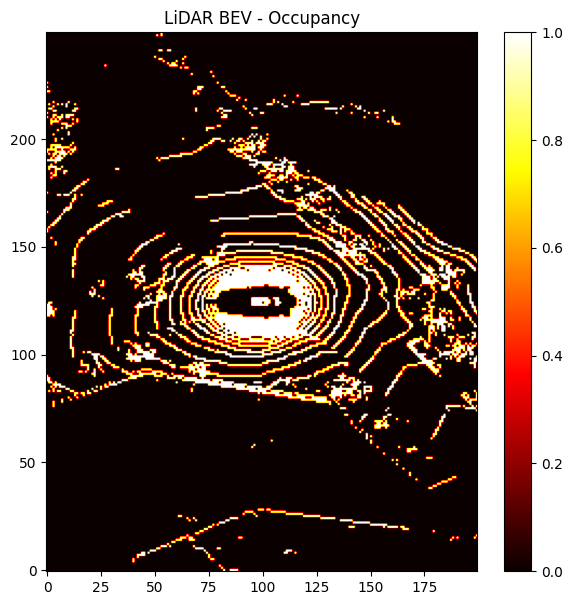

In [19]:
# Visualize occupancy
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.imshow(bev[0], cmap="hot", origin="lower")
plt.title("LiDAR BEV - Occupancy")
plt.colorbar()
plt.show()


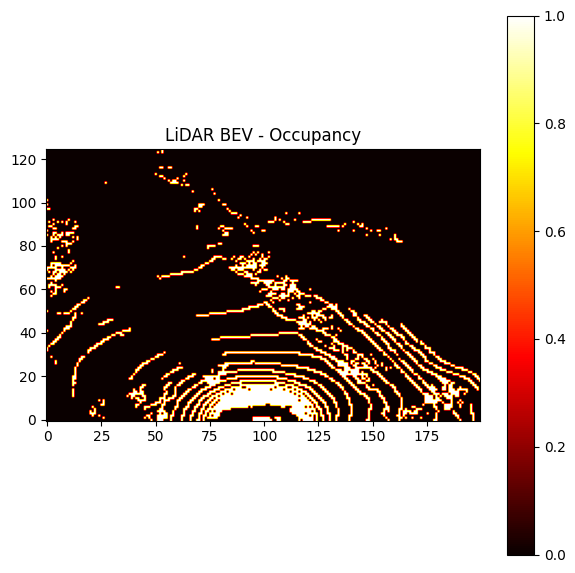

In [22]:
# Visualize occupancy
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.imshow(bev[0], cmap="hot", origin="lower")
plt.title("LiDAR BEV - Occupancy")
plt.colorbar()
plt.show()

Original: (34720, 4)
Synthetic cluster: (2000, 4)


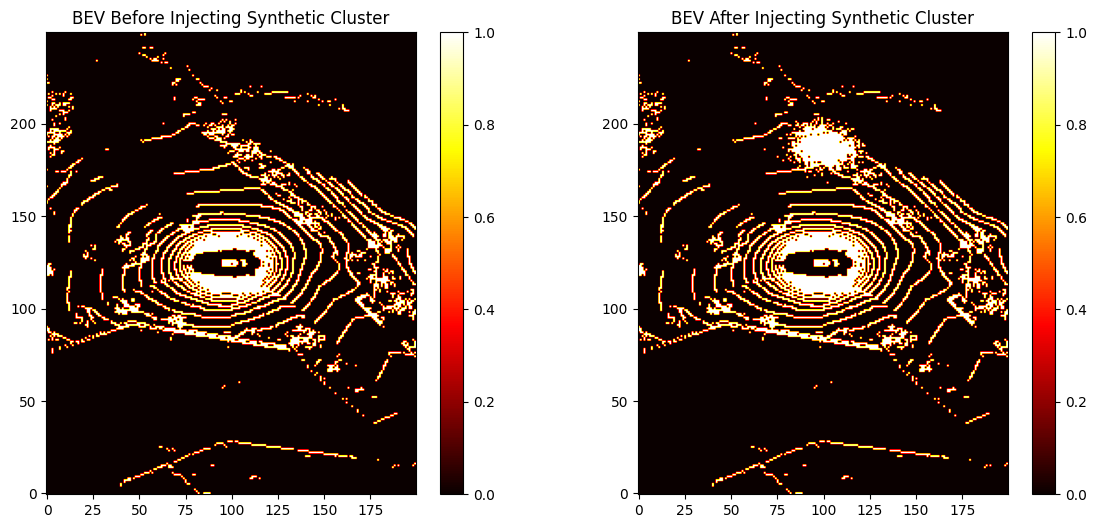

In [4]:
# ---------------------------------------------------------
# 1. Load original LiDAR (same as before)
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"

pts = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)[:, :4]  # x,y,z,intensity
print("Original:", pts.shape)


# ---------------------------------------------------------
# 2. Define BEV spec (front 50m × 50m)
# ---------------------------------------------------------
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(
    x_min=-50.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)


# ---------------------------------------------------------
# 3. Build a function converting point cloud to BEV
# ---------------------------------------------------------
def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W

    bev_occ    = np.zeros((H, W), dtype=np.float32)

    for px, py in zip(ix, iy):
        bev_occ[px, py] = 1.0

    return bev_occ


# ---------------------------------------------------------
# 4. Inject synthetic dense cluster at known position
# ---------------------------------------------------------
# Choose physical location (meters)
cluster_x = 25.0   # forward
cluster_y =  0.0   # right
cluster_z =  0.5

# Generate ~500 dense points in a small sphere
N = 2000
rng = np.random.default_rng(0)
sphere = rng.normal(scale=2, size=(N, 3))  # small 25cm cluster
sphere[:, 2] *= 0.1                            # flatten vertically

cluster_pts = np.zeros((N, 4))
cluster_pts[:, 0] = cluster_x + sphere[:, 0]
cluster_pts[:, 1] = cluster_y + sphere[:, 1]
cluster_pts[:, 2] = cluster_z + sphere[:, 2]
cluster_pts[:, 3] = 1.0  # intensity

print("Synthetic cluster:", cluster_pts.shape)

# Merge cluster with original cloud
pts_with_cluster = np.vstack([pts, cluster_pts])


# ---------------------------------------------------------
# 5. Convert to BEV maps (before + after)
# ---------------------------------------------------------
bev_before = lidar_to_bev(pts, bev_spec)
bev_after  = lidar_to_bev(pts_with_cluster, bev_spec)


# ---------------------------------------------------------
# 6. Plot: before vs after (geometric alignment test)
# ---------------------------------------------------------
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(bev_before, cmap="hot", origin="lower")
plt.title("BEV Before Injecting Synthetic Cluster")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(bev_after, cmap="hot", origin="lower")
plt.title("BEV After Injecting Synthetic Cluster")
plt.colorbar()

plt.show()


In [19]:
# ---------------------------------------------------------
# Save the modified LiDAR with synthetic cluster
# ---------------------------------------------------------

save_path = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/synthetic_n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"

# pts_with_cluster: (N, 4) = x,y,z,intensity
# NuScenes expects (N, 5) = x,y,z,intensity,ring
ring = np.zeros((pts_with_cluster.shape[0], 1), dtype=np.float32)

pts_5d = np.hstack([pts_with_cluster.astype(np.float32), ring])

print("Saving:", pts_5d.shape, "→", save_path)
pts_5d.tofile(save_path)

print("✅ Saved synthetic LiDAR file with cluster.")


Saving: (36720, 5) → /home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/synthetic_n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin
✅ Saved synthetic LiDAR file with cluster.


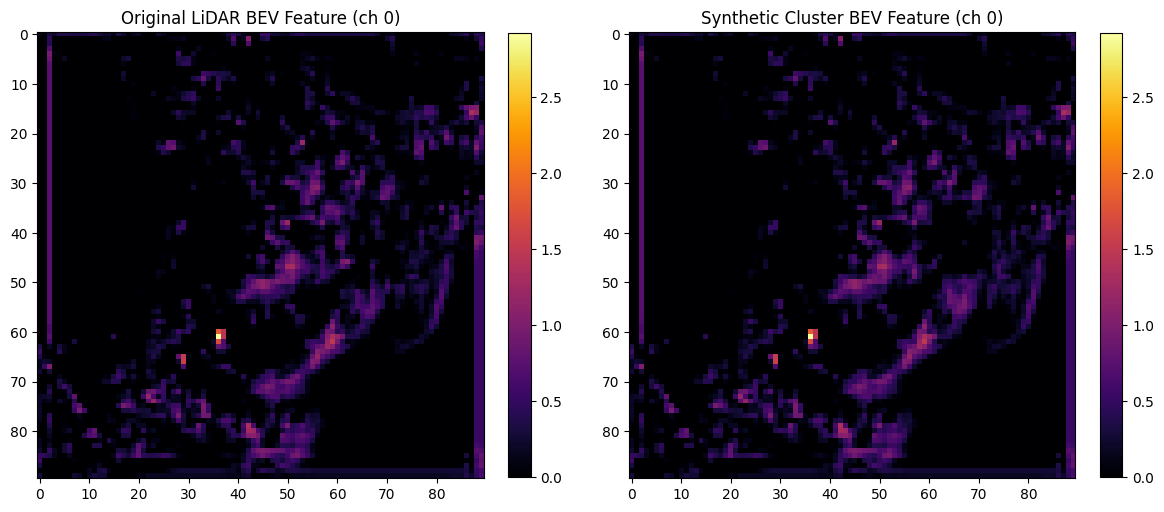

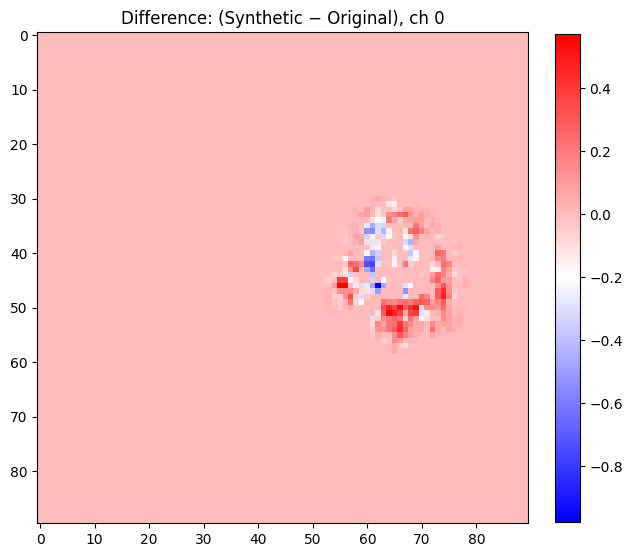

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load both features
# ============================
feat_orig  = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_1.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

feat_synth = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

# pick channel 0 or any other (CenterPoint has 256 channels)
ch = 0
orig_ch  = feat_orig[ch]
synth_ch = feat_synth[ch]

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_ch, cmap="inferno")
plt.title("Original LiDAR BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_ch, cmap="inferno")
plt.title("Synthetic Cluster BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_ch - orig_ch, cmap="bwr")
plt.title("Difference: (Synthetic − Original), ch 0")
plt.colorbar(fraction=0.045)
plt.show()



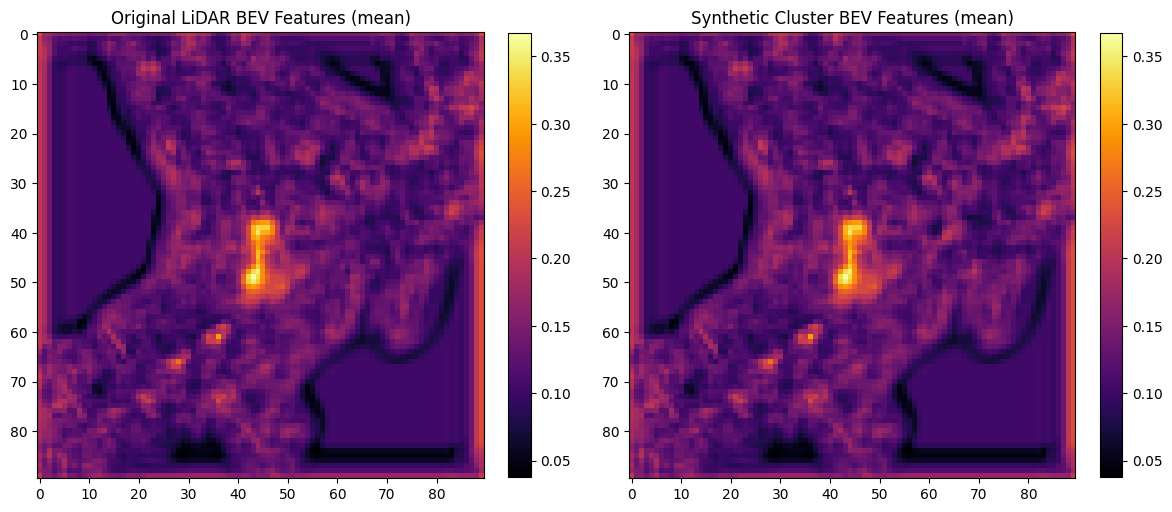

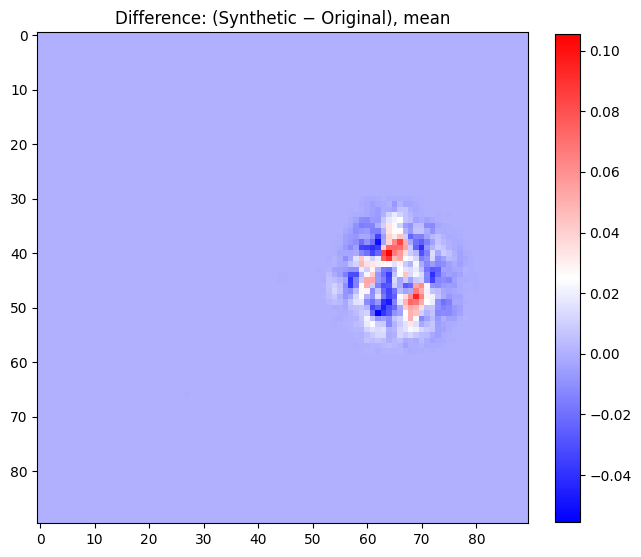

In [12]:

# pick channel 0 or any other (CenterPoint has 256 channels)

# Compute mean across channels → shape [H, W]
orig_mean  = feat_orig.mean(axis=0)
synth_mean = feat_synth.mean(axis=0)

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_mean, cmap="inferno")
plt.title("Original LiDAR BEV Features (mean)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_mean, cmap="inferno")
plt.title("Synthetic Cluster BEV Features (mean)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_mean - orig_mean, cmap="bwr")
plt.title("Difference: (Synthetic − Original), mean")
plt.colorbar(fraction=0.045)
plt.show()



visualize centerpoint earlier layers

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load both features
# ============================
feat_orig  = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

feat_synth = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_early_layers.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

# pick channel 0 or any other (CenterPoint has 256 channels)
ch = 0
orig_ch  = feat_orig[ch]
synth_ch = feat_synth[ch]

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_ch, cmap="inferno")
plt.title("Original LiDAR BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_ch, cmap="inferno")
plt.title("Synthetic Cluster BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_ch - orig_ch, cmap="bwr")
plt.title("Difference: (Synthetic − Original), ch 0")
plt.colorbar(fraction=0.045)
plt.show()



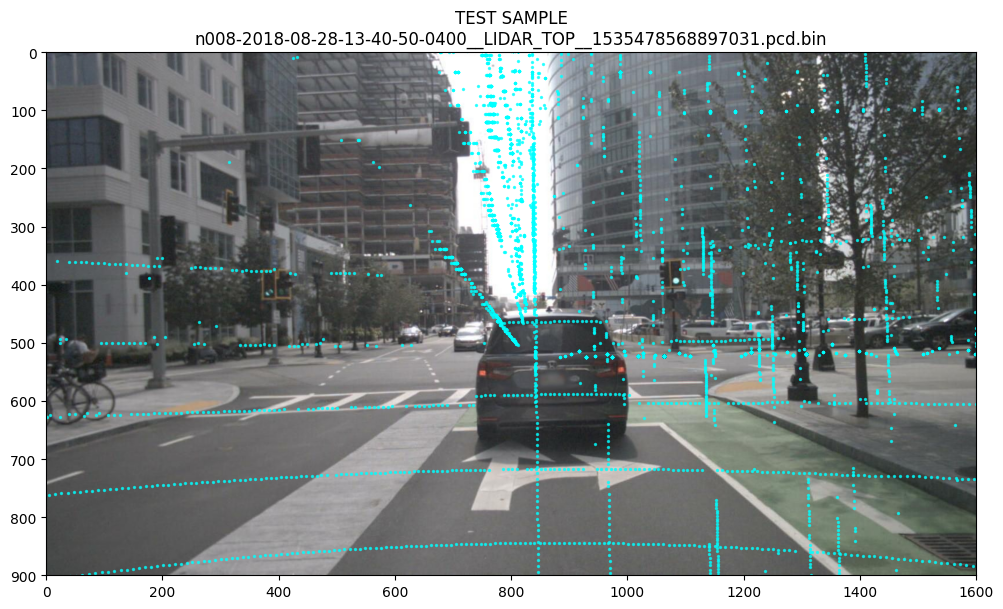

In [7]:
from pathlib import Path
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import transform_matrix, view_points
from pyquaternion import Quaternion
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------
# PATHS
# ----------------------
NUSCENES_ROOT = Path("~/Desktop/datasets/nuscenes_pseudo_test").expanduser()
NUSCENES_VERSION = "v1.0-pseudo-test"

LIDAR_FILE = "n008-2018-08-28-13-40-50-0400__LIDAR_TOP__1535478568897031.pcd.bin"
# LIDAR_FILE = "n008-2018-08-01-15-34-25-0400__LIDAR_TOP__1533152222947220.pcd.bin"
lidar_path = NUSCENES_ROOT / "samples" / "LIDAR_TOP" / LIDAR_FILE


# ----------------------
# LOAD LIDAR
# ----------------------
def load_bin_pts(path):
    arr = np.fromfile(str(path), dtype=np.float32)
    return arr.reshape(-1, 4)

pts = load_bin_pts(lidar_path)
pts_xyz = pts[:, :3]

# ----------------------
# LOAD NUSCENES TEST
# ----------------------
nusc = NuScenes(version=NUSCENES_VERSION, dataroot=str(NUSCENES_ROOT), verbose=False)

# Find sample_token
sample_token = None
for sd in nusc.sample_data:
    if sd["channel"] == "LIDAR_TOP" and sd["filename"].endswith(LIDAR_FILE):
        sample_token = sd["sample_token"]
        cam_sd_token = nusc.get("sample", sample_token)["data"]["CAM_FRONT"]
        break

if sample_token is None:
    raise RuntimeError("Could not match lidar file to sample_token.")

cam_sd = nusc.get("sample_data", cam_sd_token)
cam_fname = cam_sd["filename"]  # e.g., "samples/CAM_FRONT/..."
img_path = NUSCENES_ROOT / cam_fname


# ----------------------
# PROJECT LIDAR TO CAMERA
# ----------------------
calib_cam = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
ego_cam   = nusc.get("ego_pose", cam_sd["ego_pose_token"])

sample = nusc.get("sample", sample_token)
lid_sd_token = sample["data"]["LIDAR_TOP"]
lid_sd = nusc.get("sample_data", lid_sd_token)
calib_lid = nusc.get("calibrated_sensor", lid_sd["calibrated_sensor_token"])
ego_lid   = nusc.get("ego_pose", lid_sd["ego_pose_token"])

# homogeneous coords
pts_h = np.vstack((pts_xyz.T, np.ones((1, pts_xyz.shape[0]))))

# Lidar->ego_lid
T_lid_ego = transform_matrix(calib_lid['translation'], Quaternion(calib_lid['rotation']))
pts_ego = T_lid_ego @ pts_h

# ego_lid->global
T_ego_glob = transform_matrix(ego_lid['translation'], Quaternion(ego_lid['rotation']))
pts_glob = T_ego_glob @ pts_ego

# global->ego_cam
T_ego_cam = transform_matrix(ego_cam['translation'], Quaternion(ego_cam['rotation']))
T_glob_ego_cam = np.linalg.inv(T_ego_cam)
pts_ego_cam = T_glob_ego_cam @ pts_glob

# ego_cam->camera
T_cam_ego = transform_matrix(calib_cam['translation'], Quaternion(calib_cam['rotation']))
T_ego_cam2 = np.linalg.inv(T_cam_ego)
pts_cam = T_ego_cam2 @ pts_ego_cam
pts_cam3 = pts_cam[:3, :]

# project
intrinsic = np.array(calib_cam["camera_intrinsic"])
uv = view_points(pts_cam3, intrinsic, normalize=True)
u, v = uv[0, :], uv[1, :]
z = pts_cam3[2, :]


# ----------------------
# LOAD IMAGE
# ----------------------
img = np.array(Image.open(img_path))
H, W = img.shape[:2]

# ----------------------
# VISUALIZATION
# ----------------------
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.scatter(u[z > 0], v[z > 0], s=2, c='cyan', alpha=0.7)
plt.title(f"TEST SAMPLE\n{LIDAR_FILE}")
plt.xlim(0, W)
plt.ylim(H, 0)
plt.show()
